f=0, crack: origin to (1,0), with exact solution.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# Domain
# =========================
X_MIN, X_MAX = -1.0, 1.0
Y_MIN, Y_MAX = -1.0, 1.0
N_f = 100
N_b = 100
lam, lam_up, lam_down = 1e3, 10.0, 0.3
epochs = 3000
# =========================
# Network
# =========================
class MLP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers)-1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))
        self.act = torch.tanh

        for m in self.layers:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        for l in self.layers[:-1]:
            x = self.act(l(x))
        return self.layers[-1](x)

model = MLP([3, 30, 30, 1]).to(device)

# =========================
# Phi and derivatives
# =========================
def compute_phi(x, y):
    eps = 1e-12
    r = torch.sqrt(torch.clamp(x**2 + y**2, min=eps))
    return torch.sqrt(0.5 * (r - x))

def compute_phi_derivs(x, y):
    eps = 1e-12
    r = torch.sqrt(torch.clamp(x**2 + y**2, min=eps))
    sqrt = torch.sqrt(r - x)
    phi_x = -0.5 * sqrt / r
    phi_y = 0.5 * y / (r * sqrt)
    return phi_x, phi_y

# =========================
# Autograd helpers
# =========================
def first_derivs(model, x, y):
    phi = compute_phi(x, y)
    inp = torch.cat([x, y, phi], dim=1).requires_grad_(True)

    U = model(inp).view(-1, 1)

    grads = torch.autograd.grad(
        outputs=U.sum(),
        inputs=inp,
        create_graph=True
    )[0]

    return U, inp, grads[:,0:1], grads[:,1:2], grads[:,2:3]

def second_partials_U(inp, U_x, U_y, U_z):

    grad_Ux = torch.autograd.grad(
        outputs=U_x.sum(),
        inputs=inp,
        create_graph=True
    )[0]

    grad_Uy = torch.autograd.grad(
        outputs=U_y.sum(),
        inputs=inp,
        create_graph=True
    )[0]

    grad_Uz = torch.autograd.grad(
        outputs=U_z.sum(),
        inputs=inp,
        create_graph=True
    )[0]

    U_xx = grad_Ux[:, 0:1]
    U_xy = grad_Ux[:, 1:2]
    U_xz = grad_Ux[:, 2:3]

    U_yy = grad_Uy[:, 1:2]
    U_yz = grad_Uy[:, 2:3]

    U_zz = grad_Uz[:, 2:3]

    return U_xx, U_yy, U_xz, U_yz, U_zz

# =========================
# PDE residual
# =========================
def laplace_u(model, x, y):
    phi_x, phi_y = compute_phi_derivs(x, y)
    U, inp, U_x, U_y, U_z = first_derivs(model, x, y)
    U_xx, U_yy, U_xz, U_yz, U_zz = second_partials_U(inp, U_x, U_y, U_z)

    eps = 1e-12
    r = torch.sqrt(torch.clamp(x**2 + y**2, min=eps))

    lap = (U_xx + U_yy
           + 2*(U_xz * phi_x + U_yz * phi_y)
           + (1/(4*r))*U_zz)
    return lap

# =========================
# Crack-tip sampling
# =========================
def sample_tip(N=20, r=1e-3):
    theta = torch.linspace(0, 2*np.pi, N)
    x = (r * torch.cos(theta)).view(-1,1)
    y = (r * torch.sin(theta)).view(-1,1)
    return x.to(device), y.to(device)

# =========================
# Data sampling
# =========================
def sample_collocation(N):
    x = torch.rand(N*2,1)*(X_MAX-X_MIN)+X_MIN
    y = torch.rand(N*2,1)*(Y_MAX-Y_MIN)+Y_MIN

    mask = ~((torch.abs(y) < 1e-8) & (x >= 0))
    idx = mask.squeeze(1)  

    x = x[idx][:N]
    y = y[idx][:N]

    return x.to(device), y.to(device)


def sample_boundary(N):
    t = torch.linspace(-1,1,N).view(-1,1)
    xb = torch.cat([t, t, -torch.ones_like(t), torch.ones_like(t)])
    yb = torch.cat([-torch.ones_like(t), torch.ones_like(t), t, t])
    return xb.to(device), yb.to(device)

# =========================
# Residual vector (LM correct)
# =========================
def residual_vector(model):
    res = []

    # PDE
    lap = laplace_u(model, x_f, y_f)
    res.append(lap.view(-1))

    # Boundary
    phi_b = compute_phi(x_b, y_b)
    inp_b = torch.cat([x_b, y_b, phi_b], dim=1)
    res.append((model(inp_b) - phi_b).view(-1))

    # Crack-tip regularization 
    x_t, y_t = sample_tip()
    _, inp, U_x, U_y, U_z = first_derivs(model, x_t, y_t)
    _, _, U_xz, U_yz, U_zz = second_partials_U(inp, U_x, U_y, U_z)

    res += [U_zz.view(-1), U_xz.view(-1), U_yz.view(-1)]

    return torch.cat(res)

# =========================
# LM utilities
# =========================
def flatten_params(model):
    return torch.cat([p.view(-1) for p in model.parameters()])

def set_params(model, theta):
    i = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(theta[i:i+n].view_as(p))
        i += n

def lm_step(model, lam):
    r = residual_vector(model)
    loss = torch.dot(r, r)

    theta = flatten_params(model)
    n, m = theta.numel(), r.numel()
    J = torch.zeros(m, n, device=device)

    for i in range(m):
        grads = torch.autograd.grad(r[i], model.parameters(), retain_graph=True)
        J[i] = torch.cat([g.view(-1) for g in grads])

    A = J.T @ J + lam * torch.eye(n, device=device)
    delta = torch.linalg.solve(A, -J.T @ r)

    set_params(model, theta + delta)
    return loss.item(), theta, delta

# =========================
# Training
# =========================
x_f, y_f = sample_collocation(N_f)
x_b, y_b = sample_boundary(N_b)
loss_history = []
lam_history = []



for ep in range(epochs):
    loss0, theta_old, delta = lm_step(model, lam)

    r_new = residual_vector(model)
    loss1 = torch.dot(r_new, r_new).item()

    if loss1 < loss0:
        lam *= lam_down
        status = "accept"
    else:
        lam *= lam_up
        set_params(model, theta_old)
        status = "reject"

    loss_history.append(loss1)
    lam_history.append(lam)

    print(f"LM {ep:02d} | loss {loss1:.3e} | λ={lam:.1e} | {status}")


LM 00 | loss 3.025e+01 | λ=3.0e+02 | accept
LM 01 | loss 6.554e+00 | λ=9.0e+01 | accept
LM 02 | loss 3.940e+00 | λ=2.7e+01 | accept
LM 03 | loss 1.945e+00 | λ=8.1e+00 | accept
LM 04 | loss 5.122e-01 | λ=2.4e+00 | accept
LM 05 | loss 6.748e-02 | λ=7.3e-01 | accept
LM 06 | loss 1.696e-02 | λ=2.2e-01 | accept
LM 07 | loss 1.092e-02 | λ=6.6e-02 | accept
LM 08 | loss 1.435e-02 | λ=6.6e-01 | reject
LM 09 | loss 6.850e-03 | λ=2.0e-01 | accept
LM 10 | loss 5.153e-03 | λ=5.9e-02 | accept
LM 11 | loss 6.030e-03 | λ=5.9e-01 | reject
LM 12 | loss 4.323e-03 | λ=1.8e-01 | accept
LM 13 | loss 3.389e-03 | λ=5.3e-02 | accept
LM 14 | loss 3.463e-03 | λ=5.3e-01 | reject
LM 15 | loss 3.020e-03 | λ=1.6e-01 | accept
LM 16 | loss 2.428e-03 | λ=4.8e-02 | accept
LM 17 | loss 2.322e-03 | λ=1.4e-02 | accept
LM 18 | loss 5.585e-03 | λ=1.4e-01 | reject
LM 19 | loss 1.256e-03 | λ=4.3e-02 | accept
LM 20 | loss 1.086e-03 | λ=1.3e-02 | accept
LM 21 | loss 2.397e-03 | λ=1.3e-01 | reject
LM 22 | loss 8.280e-04 | λ=3.9e-

Relative L2 error (grid): 5.1043858793792616e-05


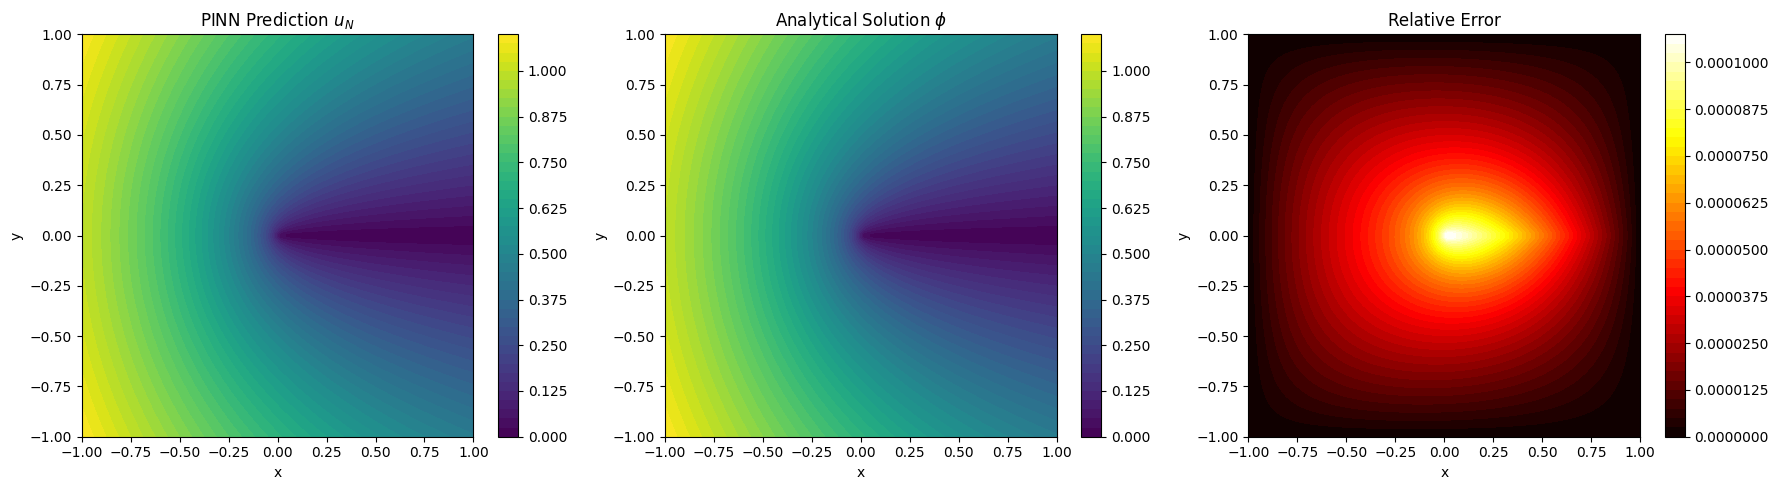

In [ ]:
def eval_u(model, x, y):
    phi = compute_phi(x, y)
    inp = torch.cat([x, y, phi], dim=1)
    return model(inp), phi

def make_grid(N=100):
    x = torch.linspace(X_MIN, X_MAX, N)
    y = torch.linspace(Y_MIN, Y_MAX, N)
    X, Y = torch.meshgrid(x, y, indexing="ij")
    return X, Y

X, Y = make_grid(100)

xg = X.reshape(-1, 1).to(device)
yg = Y.reshape(-1, 1).to(device)

with torch.no_grad():   
    Ug, U_ext = eval_u(model, xg, yg)

U = Ug.reshape(X.shape).cpu().numpy()
U_ext = U_ext.reshape(X.shape).cpu().numpy()
Xn = X.cpu().numpy()
Yn = Y.cpu().numpy()

# 逐點相對誤差
#error_rel = np.abs(u_pred - phi_grid_np) / (np.abs(phi_grid_np))
#u_inf_norm = np.max(np.abs(u_pred))   # 預測解的 inf norm
U_ext_inf_norm = np.max(np.abs(U_ext))   # 真實解的 inf norm
#error_rel = np.abs(u_pred - phi_grid_np) / (u_inf_norm) 
error_rel = np.abs(U - U_ext) / (U_ext_inf_norm)
# 整體相對誤差
error_tensor = torch.from_numpy(np.abs(U - U_ext)).double()
phi_tensor = torch.from_numpy(np.abs(U_ext)).double()
relL2 = torch.norm(error_tensor) / torch.norm(phi_tensor)
print("Relative L2 error (grid):", relL2.item())
# 畫圖
fig, axs = plt.subplots(1, 3, figsize=(18,5))

im0 = axs[0].contourf(Xn, Yn, U, 50, cmap='viridis')
fig.colorbar(im0, ax=axs[0])
axs[0].set_title('PINN Prediction $u_N$')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

im1 = axs[1].contourf(Xn, Yn, U_ext, 50, cmap='viridis')
fig.colorbar(im1, ax=axs[1])
axs[1].set_title('Analytical Solution $\\phi$')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')

im2 = axs[2].contourf(Xn, Yn, error_rel, 50, cmap='hot')
fig.colorbar(im2, ax=axs[2])
axs[2].set_title('Relative Error')
axs[2].set_xlabel('x')
axs[2].set_ylabel('y')

plt.tight_layout()
plt.show()

In [28]:
n_theta = sum(p.numel() for p in model.parameters())
print(n_theta)


1081


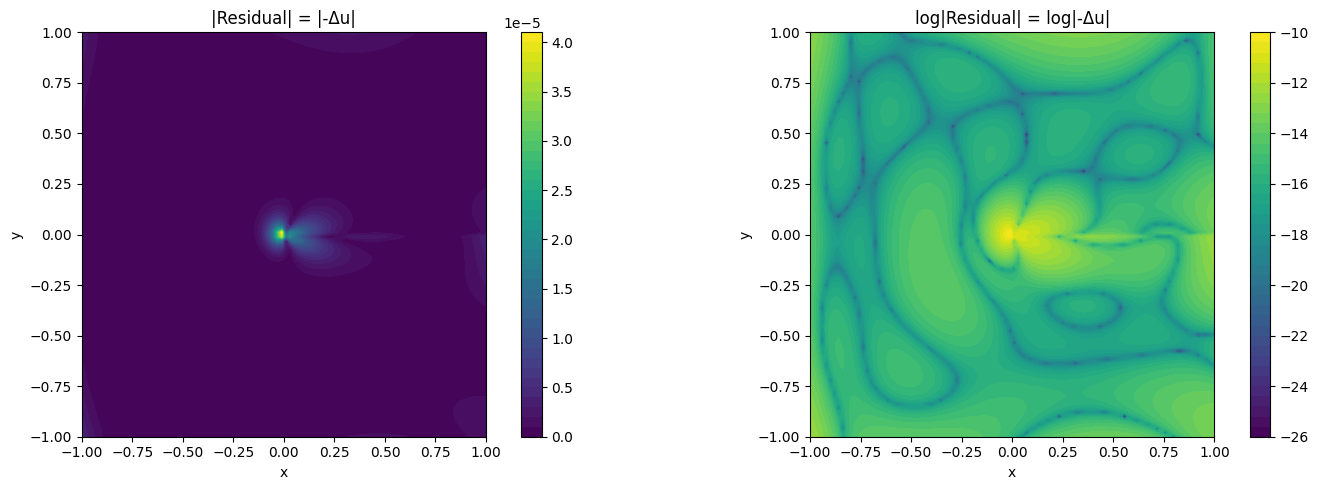

In [29]:
lap_u = laplace_u(model, xg, yg) 
residual = -lap_u
abs_residual = torch.abs(residual).detach().cpu().numpy()
log_abs_residual = torch.log(torch.abs(residual)).detach().cpu().numpy()
abs_residual = abs_residual.reshape(X.shape)
log_abs_residual = log_abs_residual.reshape(X.shape)

fig, axs = plt.subplots(1, 2, figsize=(15,5))

im0 = axs[0].contourf(X, Y, abs_residual, 50, cmap='viridis')
fig.colorbar(im0, ax=axs[0])
axs[0].set_title('|Residual| = |-Δu|')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_aspect('equal')

im1 = axs[1].contourf(X, Y, log_abs_residual, 50, cmap='viridis')
fig.colorbar(im1, ax=axs[1])
axs[1].set_title('log|Residual| = log|-Δu|')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
axs[1].set_aspect('equal')

plt.tight_layout()
plt.show()

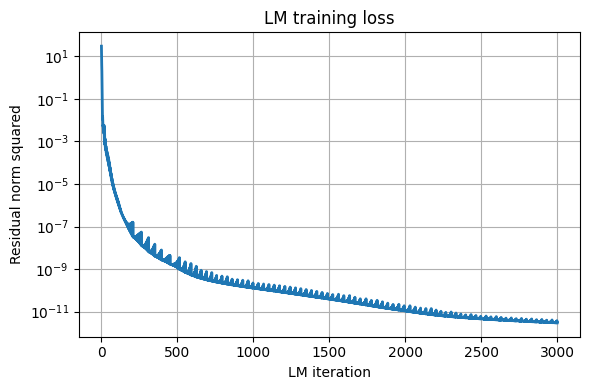

In [30]:
plt.figure(figsize=(6,4))
plt.semilogy(loss_history, lw=2)
plt.xlabel("LM iteration")
plt.ylabel("Residual norm squared")
plt.title("LM training loss")
plt.grid(True)
plt.tight_layout()
plt.show()
